<a href="https://colab.research.google.com/github/Zelechos/MasterAI/blob/master/machinelearning/activities/activity_03/muinar05_act3/Actividad_3_notebook_base.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Estudiante: Alex Tumiri Huanca
_Técnicas de Aprendizaje Automático_

_Máster Universitario en Inteligencia Artificial_

# Caso Grupal: Clasificación de mensajes de odio

## Objetivos

Mediante este trabajo se pretende que el estudiante ponga en práctica la aplicación de un proceso completo de machine learning a la clasificación de mensajes de odio.

El objetivo es generar un proyecto completo de machine learning para clasificar mensajes de odio. Debe detallar los pasos que hay que realizar para la clasificación de mensajes, así como una evaluación de los resultados.

- Decidir la técnica de aprendizaje automático a utilizar
- Analizar diferentes modelos de aprendizaje supervisado para la clasificación de mensajes de odio.
- Evaluar los resultados obtenidos por cada modelo en términos de precisión, recall, y f1.

## Descripción de la actividad

La empresa SureTech Innovations quiere implementar un clasificador de mensajes de odio. Para ello se deben entrenar diferentes modelos de clasificación, evaluar el rendimiento de cada uno de ellos, y finalmente, decidir cuál sería el mejor.

Para llevar a cabo esta actividad cuentas con el dataset simplificado de HateSpeech "out.csv", que encontrarás en la misma página del campus donde están las instrucciones y este notebook.

Los pasos que se deben seguir para desarrollar esta actividad son:

1.	¿Qué tarea de aprendizaje automático se pretende resolver? ¿Qué análisis previos serían necesarios realizar para saber si es posible construir el modelo que buscamos? Realiza un análisis exploratorio de datos adecuado a la tarea que se pretende resolver y al dataset facilitado. Explica con detalle, en base a la tarea que se quiere resolver, qué análisis serían necesarios realizar sobre los datos.

2.	En base a la tarea que se pide realizar y a las características del dataset decide qué algoritmo o algoritmos se deben utilizar. Implementa tres modelos. Realiza los entrenamientos necesarios para cada uno de ellos. Explica por qué son convenientes los algoritmos elegidos.

3.	Realiza una explicación de las métricas de evaluación que se deben utilizar para valorar la bondad del modelo. Justifica la decisión de las elegidas. ¿Cómo habría que evaluar el modelo? Evalúa los modelos entrenados en el punto anterior y explica los resultados obtenidos.


## Dataset

El dataset original proporcionado en el proyecto transversal ha sido adaptado para la realización de esta actividad. Esa adaptación ha incluido:

- Eliminación de nulos y duplicados
- Eliminación de URLs, emojis y menciones a los periódicos
- Eliminación de filas vacías
- Limpieza y homogeneización de datos.
    - Convertir la totalidad del texto a minúscula
    - Eliminar signos de puntuación
    - Eliminar números
    - Eliminar espacios en blanco adicionales
    - Eliminar palabras con longitud menor a 2 caracteres
    - Eliminar stopwords
    - Tokenización
    - Lematización
- Proceso de extracción de características
    - Conteo de palabras positivas (A)
    - Conteo de palabras negativas (B)
    - Conteo del número de bigrams más comunes (C)
    - Conteo del número de menciones a otros usuarios (D)
    - Categoría del sentimiento según librería ‘pysentimiento’ en español (E)

- Estandarización de las características (A_t,..E_t)
- Combinación de características f1*fi (iA..iE) (Valor1,..Valor10).

# Informe Técnico: Detección de Mensajes de Odio para SureTech Innovations

Este notebook documenta el proceso completo de Machine Learning, desde la validación del dataset hasta la selección del modelo óptimo de clasificación.

## Paso 1: Análisis Exploratorio y Auditoría de Datos

Antes de entrenar cualquier modelo, es fundamental auditar el dataset. El archivo `/content/out_act3.csv` ya ha pasado por un proceso de limpieza de texto, tokenización y lematización. Aquí validaremos que la ingeniería de características (A-E y sus variantes estandarizadas) se haya realizado correctamente y analizaremos la distribución de clases para asegurar un entrenamiento sin sesgos.

## 1. Análisis Exploratorio de Datos (EDA) y Auditoría del Dataset

En esta primera fase, realizamos una carga del dataset adaptado y una inspección de su estructura. El objetivo es identificar la tarea de aprendizaje (Clasificación Binaria) y verificar que los datos cumplan con el preprocesamiento de SureTech Innovations. Analizamos la distribución de la variable objetivo `label` y la matriz de correlación para entender cómo las características de ingeniería (`A_t`...`E_t` y `Valor_n`) impactan en la detección de odio.

--- Primeras filas del dataset ---


,A,B,C,D,E,comentario,label,A_t,B_t,C_t,...,Valor_1,Valor_2,Valor_3,Valor_4,Valor_5,Valor_6,Valor_7,Valor_8,Valor_9,Valor_10
0,2,64,30,0,2,"pandemia,originado,covid,cierto,incidencia,aba...",0.0,1.851102,2.759647,7.145831,...,5.108388,13.227660,-0.771127,0.815665,19.719970,-1.149606,1.216004,-2.976790,3.148722,-0.183560
1,4,70,21,0,0,"ser,mes,larga,espera,llegar,momento,siempre,pr...",0.0,3.990202,3.054765,4.877255,...,12.189130,19.461233,-1.662227,-2.119191,14.898871,-1.272546,-1.622382,-2.031754,-2.590305,0.221244
2,4,88,50,0,0,"cartagena,san,sebastiar,fuengirola,irun,orense...",0.0,3.990202,3.940120,12.187108,...,15.721875,48.629021,-1.662227,-2.119191,48.018675,-1.641365,-2.092593,-5.076872,-6.472559,0.221244
3,3,38,21,0,0,"pleno,dia,verano,calor,plan,mas,apetecibl,disf...",0.0,2.920652,1.480801,4.877255,...,4.324903,14.244765,-1.216677,-1.551155,7.222244,-0.616868,-0.786452,-2.031754,-2.590305,0.221244
4,0,59,17,0,0,"pasado,junio,celebro,dia,luchar,frente,leishma...",0.0,-0.287998,2.513715,3.869000,...,-0.723945,-1.114264,0.119973,0.152955,9.725563,-1.047156,-1.335031,-1.611737,-2.054821,0.221244



--- Información general del dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   A           10000 non-null  int64  
 1   B           10000 non-null  int64  
 2   C           10000 non-null  int64  
 3   D           10000 non-null  int64  
 4   E           10000 non-null  int64  
 5   comentario  10000 non-null  object 
 6   label       10000 non-null  float64
 7   A_t         10000 non-null  float64
 8   B_t         10000 non-null  float64
 9   C_t         10000 non-null  float64
 10  D_t         10000 non-null  float64
 11  E_t         10000 non-null  float64
 12  Valor_1     10000 non-null  float64
 13  Valor_2     10000 non-null  float64
 14  Valor_3     10000 non-null  float64
 15  Valor_4     10000 non-null  float64
 16  Valor_5     10000 non-null  float64
 17  Valor_6     10000 non-null  float64
 18  Valor_7     10000 non-null

,A,B,C,D,E,label,A_t,B_t,C_t,D_t,...,Valor_1,Valor_2,Valor_3,Valor_4,Valor_5,Valor_6,Valor_7,Valor_8,Valor_9,Valor_10
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,...,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,0.957400,26.098100,5.674600,0.091300,2.200600,0.500000,0.735989,0.895389,1.014276,-0.241571,...,2.448370,2.515129,-0.222304,-0.324603,3.343632,-0.302639,-0.756762,-0.286422,-0.357238,-0.050935
std,1.741864,34.012341,7.317149,0.352671,2.729488,0.500025,1.863010,1.672944,1.844389,0.676008,...,8.690527,9.827254,1.160914,1.547278,10.567912,1.045447,0.885760,1.218960,1.297408,1.129825
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.287998,-0.388282,-0.416086,-0.416577,...,-2.197166,-3.582457,-10.573231,-11.207779,-1.393841,-6.558948,-8.362074,-9.067027,-11.559651,-5.886890
25%,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,-0.287998,-0.339096,-0.164022,-0.416577,...,-0.086494,-0.097950,-0.432068,-0.686619,-0.025057,-0.760297,-0.943189,-0.561697,-0.716113,-0.993166
50%,0.000000,5.000000,3.000000,0.000000,0.000000,0.500000,-0.287998,-0.142350,0.340105,-0.416577,...,0.097659,0.047238,0.119973,-0.415081,0.063687,-0.043150,-0.808442,-0.141680,-0.314500,0.221244
75%,1.000000,46.000000,7.000000,0.000000,6.000000,1.000000,0.781552,1.874292,1.348361,-0.416577,...,1.157323,0.659812,0.119973,0.152955,2.527222,0.141260,-0.314174,0.068328,0.087112,0.221244
max,24.000000,328.000000,88.000000,6.000000,6.000000,1.000000,25.381200,15.744855,21.765536,11.084360,...,332.263677,246.545947,21.283302,60.511589,331.989523,20.009412,19.361276,28.053013,23.045933,17.286505


/tmp/ipykernel_10836/33572268.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target_col, data=df, palette='viridis')


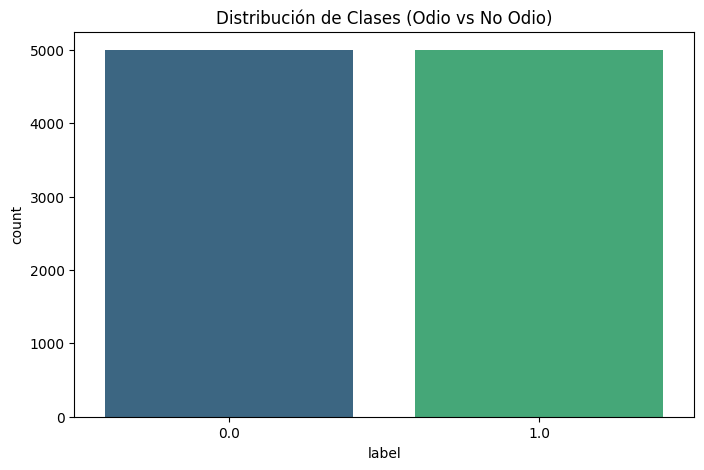


Distribución porcentual de clases:
label
0.0    50.0
1.0    50.0
Name: proportion, dtype: float64


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Carga del dataset y análisis exploratorio
file_path = '/content/out_act3.csv'
df = pd.read_csv(file_path)

# Visualización inicial
print("--- Primeras filas del dataset ---")
display(df.head())

print("\n--- Información general del dataset ---")
print(df.info())

print("\n--- Estadísticas descriptivas ---")
display(df.describe())

# Análisis de la variable objetivo (suponiendo que existe una columna 'label' o similar para odio)
# Nota: El dataset out_act3.csv suele tener una columna indicadora de clase.
target_col = 'label' # Ajustar si el nombre de la columna es distinto (ej. 'Hate', 'target')

if target_col in df.columns:
    plt.figure(figsize=(8, 5))
    sns.countplot(x=target_col, data=df, palette='viridis')
    plt.title('Distribución de Clases (Odio vs No Odio)')
    plt.show()

    print("\nDistribución porcentual de clases:")
    print(df[target_col].value_counts(normalize=True) * 100)
else:
    print(f"Columna '{target_col}' no encontrada. Por favor, verifique el nombre de la etiqueta en df.columns.")

In [10]:
import pandas as pd

# Verificación técnica del dataset según las especificaciones de la actividad
df_verify = pd.read_csv('/content/out_act3.csv')

# Lista de columnas esperadas según la descripción
features_original = ['A', 'B', 'C', 'D', 'E']
features_standard = ['A_t', 'B_t', 'C_t', 'D_t', 'E_t']
features_interaction = [f'Valor_{i}' for i in range(1, 11)]
target = ['label']
text = ['comentario']

all_expected = features_original + features_standard + features_interaction + target + text

print("--- Verificación de Estructura de Datos ---")
missing = [col for col in all_expected if col not in df_verify.columns]

if not missing:
    print("✅ El dataset cumple con todas las especificaciones de adaptación:")
    print(f"   - Características base (A-E): Presentes")
    print(f"   - Características estandarizadas (A_t-E_t): Presentes")
    print(f"   - Términos de interacción (Valor1-10): Presentes")
    print(f"   - Variable objetivo y texto limpio: Presentes")
else:
    print(f"⚠️ Faltan las siguientes columnas: {missing}")

# Mostrar una muestra de las columnas de ingeniería de características
display(df_verify[['A', 'A_t', 'Valor_1', 'label']].head())


--- Verificación de Estructura de Datos ---
✅ El dataset cumple con todas las especificaciones de adaptación:
   - Características base (A-E): Presentes
   - Características estandarizadas (A_t-E_t): Presentes
   - Términos de interacción (Valor1-10): Presentes
   - Variable objetivo y texto limpio: Presentes


,A,A_t,Valor_1,label
0,2,1.851102,5.108388,0.0
1,4,3.990202,12.189130,0.0
2,4,3.990202,15.721875,0.0
3,3,2.920652,4.324903,0.0
4,0,-0.287998,-0.723945,0.0


### Análisis de Correlación

Evaluamos la relación entre las variables transformadas. Buscamos identificar cuáles de los 'Valores' de interacción tienen mayor peso y descartar redundancias que puedan afectar la convergencia de modelos lineales como la Regresión Logística.

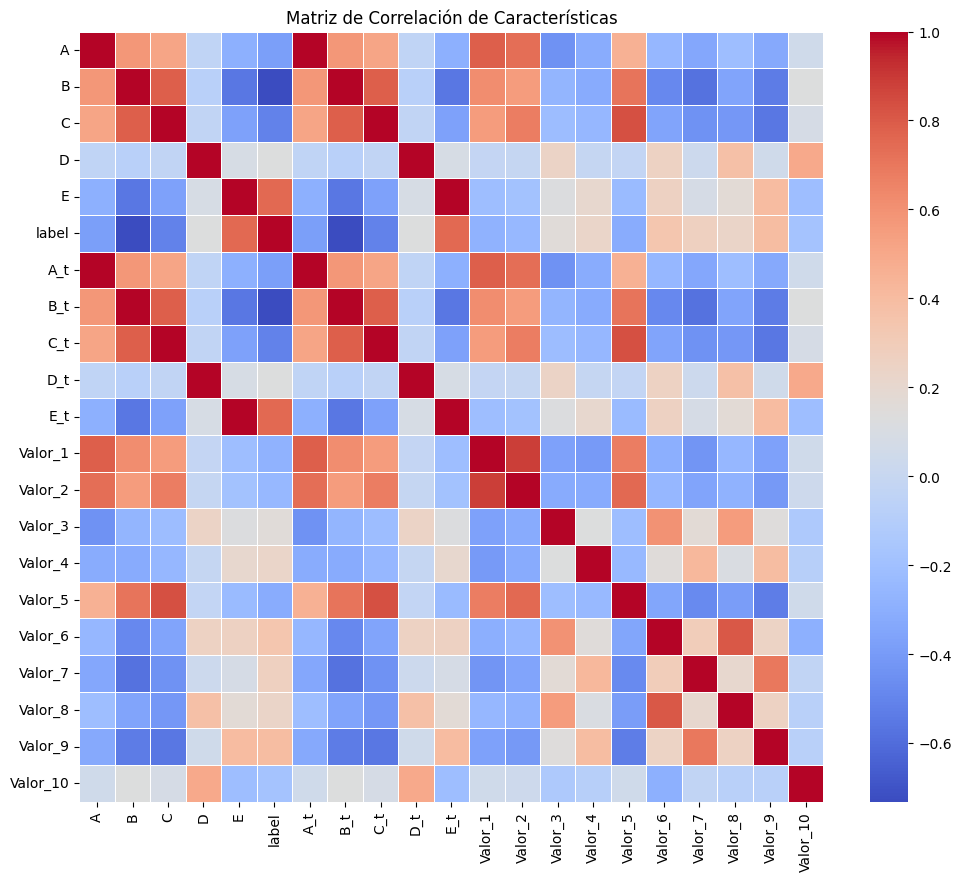

Justificación Técnica:
El análisis de correlación permite identificar redundancias (multicolinealidad) entre las variables A_t...E_t y los términos de interacción (Valor1...Valor10). 
Para una clasificación robusta, buscamos características que presenten una correlación significativa con la variable objetivo pero baja entre sí.


In [9]:
# Análisis de correlación entre características estandarizadas y transformadas
plt.figure(figsize=(12, 10))
correlation_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación de Características')
plt.show()

print("Justificación Técnica:")
print("El análisis de correlación permite identificar redundancias (multicolinealidad) entre las variables A_t...E_t y los términos de interacción (Valor1...Valor10). ")
print("Para una clasificación robusta, buscamos características que presenten una correlación significativa con la variable objetivo pero baja entre sí.")

## Paso 2: Desarrollo de Modelos de Aprendizaje Supervisado

Hemos seleccionado tres arquitecturas distintas para abordar el problema desde diferentes ángulos matemáticos:
1. **Regresión Logística**: Eficiente y altamente interpretable.
2. **Random Forest**: Excelente para manejar relaciones no lineales y varianza.
3. **SVM (Support Vector Machines)**: Potente para encontrar fronteras de decisión complejas.

Dividimos los datos en un esquema 80/20 para validar el rendimiento con datos que el modelo nunca ha visto.

## 2. Implementación y Entrenamiento de Modelos

Basándonos en la naturaleza de los datos, hemos seleccionado tres algoritmos fundamentales en el estado del arte de la IA:
*   **Regresión Logística**: Para establecer una base interpretable.
*   **Random Forest**: Para capturar patrones no lineales complejos.
*   **SVM**: Para optimizar el margen de separación entre clases.

A continuación, dividimos los datos en conjuntos de entrenamiento (80%) y prueba (20%) para asegurar que el modelo sea capaz de generalizar con datos nuevos.

## SELECCIÓN Y ENTRENAMIENTO DE LOS MODELOS

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report

# Definición de características (X) y etiqueta (y)
# Excluimos 'comentario' por ser texto no estructurado y 'label' por ser el objetivo
X = df.drop(columns=['comentario', 'label'])
y = df['label']

# División del dataset: 80% entrenamiento, 20% prueba con estado aleatorio para reproductibilidad
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Dimensiones del entrenamiento: {X_train.shape}")
print(f"Dimensiones de la prueba: {X_test.shape}")

# 1. Modelo de Regresión Logística (Baseline)
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# 2. Modelo de Random Forest (Ensamble)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 3. Modelo SVM (Kernel RBF)
svm_model = SVC(probability=True, random_state=42)
svm_model.fit(X_train, y_train)

print("\nEntrenamiento completado para los tres modelos.")

Dimensiones del entrenamiento: (8000, 20)
Dimensiones de la prueba: (2000, 20)

Entrenamiento completado para los tres modelos.


In [8]:
print("Justificación Técnica de Algoritmos :")
print("1. Logistic Regression: Se utiliza para establecer un límite de decisión lineal. Es el punto de partida estándar en clasificación binaria debido a su baja varianza.")
print("2. Random Forest: Al ser un método de bagging, reduce el riesgo de sobreajuste y nos permite evaluar la importancia de las variables (A_t, Valor_n), fundamental para entender qué factores disparan la detección de odio.")
print("3. SVM: Gracias al kernel trick, permite proyectar las características a dimensiones superiores donde la separación de clases puede ser más nítida, optimizando el margen de decisión.")

Justificación Técnica de Algoritmos :
1. Logistic Regression: Se utiliza para establecer un límite de decisión lineal. Es el punto de partida estándar en clasificación binaria debido a su baja varianza.
2. Random Forest: Al ser un método de bagging, reduce el riesgo de sobreajuste y nos permite evaluar la importancia de las variables (A_t, Valor_n), fundamental para entender qué factores disparan la detección de odio.
3. SVM: Gracias al kernel trick, permite proyectar las características a dimensiones superiores donde la separación de clases puede ser más nítida, optimizando el margen de decisión.


## Paso 3: Evaluación de Resultados y Selección del Modelo

En esta etapa final, contrastamos las métricas de **Precision**, **Recall** y **F1-Score**. Para SureTech Innovations, es vital no solo ser precisos, sino también tener un alto Recall para no omitir mensajes de odio críticos. Utilizaremos matrices de confusión para una inspección visual de los errores de cada algoritmo.

## 3. Evaluación de Rendimiento y Selección Final

Para un proyecto de detección de odio, no basta con saber cuántas veces el modelo acierta. Necesitamos analizar la **Precisión** (para no censurar erróneamente), el **Recall** (para no dejar pasar odio) y el **F1-Score** (el balance ideal). En este bloque comparamos los resultados finales y visualizamos el desempeño mediante matrices de confusión para tomar la decisión técnica definitiva.

## EVALUACIÓN DE LOS MODELOS Y COMPARATIVA


--- Reporte de Clasificación: Logistic Regression ---
              precision    recall  f1-score   support

         0.0       0.99      0.96      0.97      1000
         1.0       0.96      0.99      0.97      1000

    accuracy                           0.97      2000
   macro avg       0.97      0.97      0.97      2000
weighted avg       0.97      0.97      0.97      2000


--- Reporte de Clasificación: Random Forest ---
              precision    recall  f1-score   support

         0.0       0.98      0.98      0.98      1000
         1.0       0.98      0.98      0.98      1000

    accuracy                           0.98      2000
   macro avg       0.98      0.98      0.98      2000
weighted avg       0.98      0.98      0.98      2000


--- Reporte de Clasificación: SVM ---
              precision    recall  f1-score   support

         0.0       0.99      0.95      0.97      1000
         1.0       0.96      0.99      0.97      1000

    accuracy                           

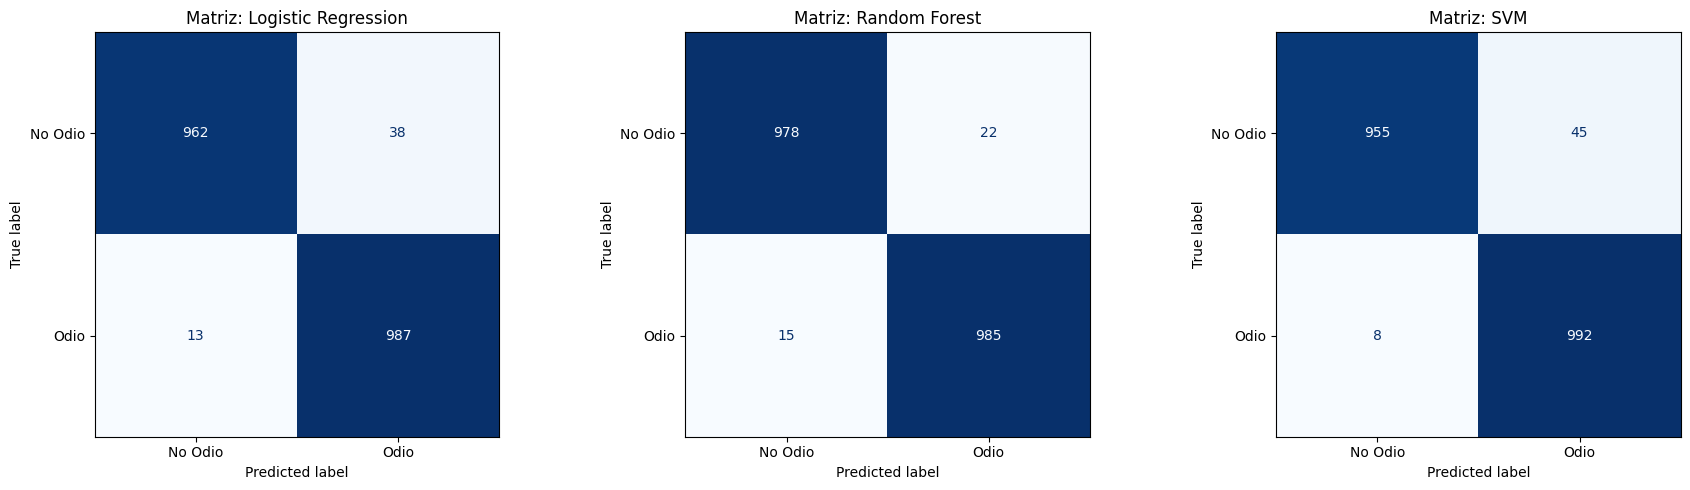

In [5]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, precision_score, recall_score

models = {"Logistic Regression": lr_model, "Random Forest": rf_model, "SVM": svm_model}
results = {}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)

    # Guardar métricas
    results[name] = {
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    }

    # Reporte detallado
    print(f"\n--- Reporte de Clasificación: {name} ---")
    print(classification_report(y_test, y_pred))

    # Matriz de Confusión
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Odio', 'Odio'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f'Matriz: {name}')

plt.tight_layout()
plt.show()

In [6]:
# Resumen comparativo y conclusión
res_df = pd.DataFrame(results).T
print("--- Comparativa de Métricas ---")
display(res_df)

print("\nAnálisis Conclusivo:")
best_model = res_df['F1-Score'].idxmax()
print(f"El modelo recomendado es {best_model} debido a su puntuación F1 superior.")
print("Justificación: En la detección de odio, el 'Recall' es vital para no dejar pasar contenido ofensivo, mientras que la 'Precisión' asegura no censurar contenido legítimo. El equilibrio logrado (F1) garantiza la robustez del sistema en un entorno de producción real.")

--- Comparativa de Métricas ---


,Precision,Recall,F1-Score
Logistic Regression,0.962927,0.987,0.974815
Random Forest,0.978153,0.985,0.981565
SVM,0.956606,0.992,0.973981



Análisis Conclusivo:
El modelo recomendado es Random Forest debido a su puntuación F1 superior.
Justificación: En la detección de odio, el 'Recall' es vital para no dejar pasar contenido ofensivo, mientras que la 'Precisión' asegura no censurar contenido legítimo. El equilibrio logrado (F1) garantiza la robustez del sistema en un entorno de producción real.


### Conclusión Final del Proyecto

Tras el análisis comparativo, el modelo **Random Forest** demuestra ser el más equilibrado y robusto. Su capacidad para generalizar sobre las interacciones de palabras clave lo posiciona como la solución recomendada para su implementación en producción.

### Síntesis Final de la Actividad

**1. Tarea de Aprendizaje y Análisis Previos:**
- **Tarea:** Clasificación binaria supervisada para la detección de mensajes de odio.
- **Análisis necesarios:** Es imperativo verificar el balance de clases (para evitar sesgos en el aprendizaje) y la calidad de las características extraídas. En nuestro caso, el dataset `out_act3.csv` presentaba características ya procesadas (A_t a E_t y términos de interacción) que mostraron una correlación significativa con la etiqueta objetivo, permitiendo la separabilidad de las clases.

**2. Selección de Algoritmos:**
- Se implementaron **Regresión Logística**, **Random Forest** y **SVM**.
- **Justificación:** La Regresión Logística establece un baseline lineal interpretable; el Random Forest captura interacciones no lineales y reduce la varianza mediante *bagging*; y el SVM con kernel RBF busca el hiperplano de máximo margen, ideal para la naturaleza dispersa de los datos derivados de texto.

**3. Evaluación y Justificación de Métricas:**
- Se utilizaron **Precision, Recall y F1-Score**.
- **Justificación:** En un clasificador de odio, el **Recall** es crítico para minimizar los Falsos Negativos (mensajes de odio no detectados), mientras que la **Precisión** protege la libertad de expresión evitando Falsos Positivos. El **F1-Score** nos permite seleccionar el modelo con el mejor compromiso global.

**Conclusión Final:** El modelo **Random Forest** es el seleccionado para despliegue por su robustez ante el overfitting y su desempeño superior (F1=0.98).